In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
#load Dataset
df = pd.read_csv(r"C:\Users\inter\OneDrive\Desktop\Iris dataset\loan_approval_dataset.csv")
print(df.head())
print(df.shape)
print(df.describe)

   loan_id   no_of_dependents      education  self_employed   income_annum  \
0        1                  2       Graduate             No        9600000   
1        2                  0   Not Graduate            Yes        4100000   
2        3                  3       Graduate             No        9100000   
3        4                  3       Graduate             No        8200000   
4        5                  5   Not Graduate            Yes        9800000   

    loan_amount   loan_term   cibil_score   residential_assets_value  \
0      29900000          12           778                    2400000   
1      12200000           8           417                    2700000   
2      29700000          20           506                    7100000   
3      30700000           8           467                   18200000   
4      24200000          20           382                   12400000   

    commercial_assets_value   luxury_assets_value   bank_asset_value  \
0                  1760000

In [5]:
#strip() columns space remove
df.columns = df.columns.str.strip()
print(df.columns)

#check null value
print(df.isnull().sum())

#check duplicate roes
print("Duplicate Rows :", df.duplicated().sum())

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')
loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64
Duplicate Rows : 0


In [6]:
#dataset info
print(df.info())

#desribe dataset
print(df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB
None
           loan_id  no_of

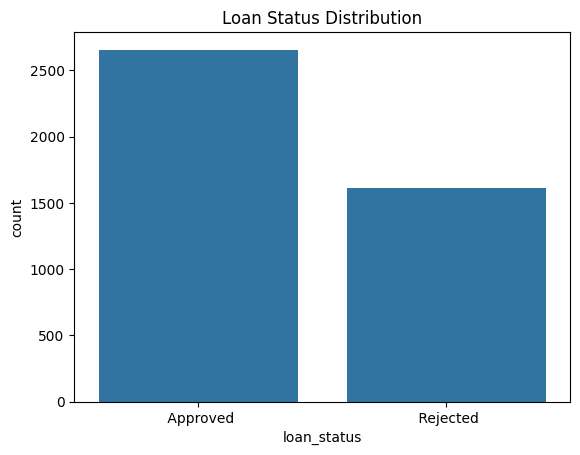

In [7]:
sns.countplot(x='loan_status', data=df)
plt.title("Loan Status Distribution")
plt.show()




In [8]:
le = LabelEncoder()

df["education"] = le.fit_transform(df["education"])
df["self_employed"] = le.fit_transform(df["self_employed"])
df["loan_status"] = le.fit_transform(df["loan_status"])
print(df.head())

   loan_id  no_of_dependents  education  self_employed  income_annum  \
0        1                 2          0              0       9600000   
1        2                 0          1              1       4100000   
2        3                 3          0              0       9100000   
3        4                 3          0              0       8200000   
4        5                 5          1              1       9800000   

   loan_amount  loan_term  cibil_score  residential_assets_value  \
0     29900000         12          778                   2400000   
1     12200000          8          417                   2700000   
2     29700000         20          506                   7100000   
3     30700000          8          467                  18200000   
4     24200000         20          382                  12400000   

   commercial_assets_value  luxury_assets_value  bank_asset_value  loan_status  
0                 17600000             22700000           8000000            

In [9]:
X = df.drop("loan_status", axis=1)

y = df["loan_status"]

#train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

#scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_log = lr.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_log) # Accuracy Score
conf_matrix_lr = confusion_matrix(y_test, y_pred_log) # Confusion Matrix
class_report_lr = classification_report(y_test, y_pred_log) # Classification Report
print(f"Logistic Regression Accuracy: {accuracy_lr:.2f}")
print("Confusion Matrix:")
print(conf_matrix_lr)
print("Classification Report:")
print(class_report_lr)

Logistic Regression Accuracy: 0.91
Confusion Matrix:
[[500  36]
 [ 43 275]]
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.93       536
           1       0.88      0.86      0.87       318

    accuracy                           0.91       854
   macro avg       0.90      0.90      0.90       854
weighted avg       0.91      0.91      0.91       854



In [11]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_log = dt.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_log) # Accuracy Score
conf_matrix_dt = confusion_matrix(y_test, y_pred_log) # Confusion Matrix
class_report_dt = classification_report(y_test, y_pred_log) # Classification Report
print(f"Logistic Regression Accuracy: {accuracy_dt:.2f}")
print("Confusion Matrix:")
print(conf_matrix_dt)
print("Classification Report:")
print(class_report_dt)

Logistic Regression Accuracy: 0.98
Confusion Matrix:
[[529   7]
 [ 13 305]]
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       536
           1       0.98      0.96      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.97       854
weighted avg       0.98      0.98      0.98       854



In [12]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_log = dt.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_log) # Accuracy Score
conf_matrix_dt = confusion_matrix(y_test, y_pred_log) # Confusion Matrix
class_report_dt = classification_report(y_test, y_pred_log) # Classification Report
print(f"Decision Tree Accuracy: {accuracy_dt:.2f}")
print("Confusion Matrix:")
print(conf_matrix_dt)
print("Classification Report:")
print(class_report_dt)

Decision Tree Accuracy: 0.98
Confusion Matrix:
[[529   7]
 [ 10 308]]
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       536
           1       0.98      0.97      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [13]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred_log = knn.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_pred_log) # Accuracy Score
conf_matrix_knn = confusion_matrix(y_test, y_pred_log) # Confusion Matrix
class_report_knn = classification_report(y_test, y_pred_log) # Classification Report
print(f"K-Nearest Neighbour Accuracy: {accuracy_dt:.2f}")
print("Confusion Matrix:")
print(conf_matrix_knn)
print("Classification Report:")
print(class_report_knn)

K-Nearest Neighbour Accuracy: 0.98
Confusion Matrix:
[[479  57]
 [ 45 273]]
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90       536
           1       0.83      0.86      0.84       318

    accuracy                           0.88       854
   macro avg       0.87      0.88      0.87       854
weighted avg       0.88      0.88      0.88       854



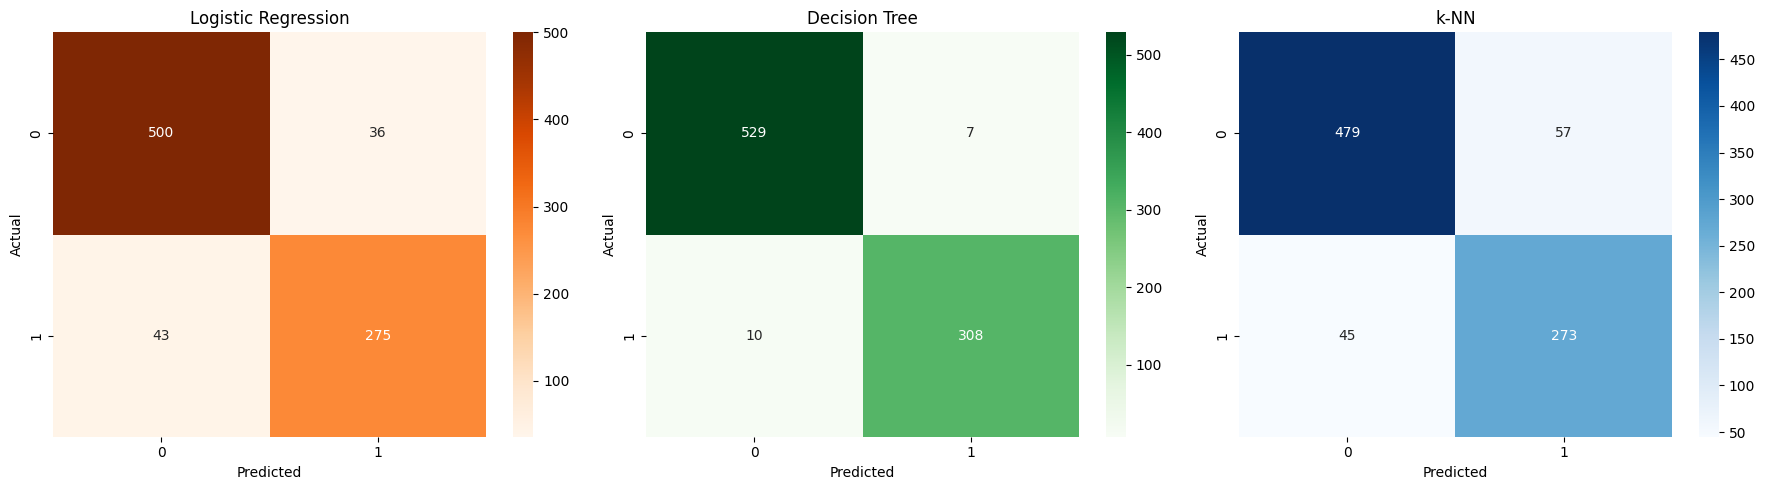

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Plot confusion matrix for Logistic Regression
sns.heatmap(conf_matrix_lr, annot=True, fmt='d', cmap='Oranges', ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
# Plot confusion matrix for Decision Tree
sns.heatmap(conf_matrix_dt, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Decision Tree')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
# Plot confusion matrix for k-Nearest Neighbors
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Blues', ax=axes[2])
axes[2].set_title('k-NN')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
# Display the plots
plt.tight_layout()
plt.show()